#   *Non-Invasive Jaundice Detection Using Machine Learning SMOTE*


## Jaundiced Newborns
##### Neonatal jaundice presents a substantial health concern for newborns, potentially resulting in severe complications, including permanent brain damage if not addressed promptly in its early stages. Conventional detection methods often entail invasive procedures like blood sample collection, which not only cause distress to the infant but also pose additional risks.

#####  Our study utilized advanced methodologies, employing the SMOTE and Voting soft, incorporating two distinct algorithms: Gradient Boosting and ExtraTrees. This technique harnesses the collective wisdom of multiple models to enhance predictive accuracy and robustness and to develop a robust classifier capable of accurately identifying jaundice from infant images.

##### We made use of the NJN collection, a carefully curated repository of newborn images covering various birthweights and skin tones, spanning an age range from 2 to 8 days. This dataset, accompanied by detailed RGB and YCrCb channel values for each sample, serves as a valuable resource for training AI systems dedicated to diagnosing neonatal jaundice.

##### The performance metrics of our classifier illustrate its effectiveness, voting soft  Gradient Boosting and ExtraTrees an accuracy of 99.34%, precision of 98.80%, recall of 99.55%, F1 score of 98.80%,AUC of 99.55% and MCC of 98.36%. These outcomes, validated by a confusion matrix and further supported by an AUC of 0.996, underscore the reliability and potential clinical utility of our approach.

##### By furnishing a swift, real-time, and accurate method of jaundice detection, our research aims to equip neonatal intensive care unit (NICU) healthcare specialists with the tools necessary for effectively monitoring newborns, thereby mitigating the risks associated with this prevalent yet treatable condition. This endeavor signifies a significant stride towards enhancing neonatal care through the amalgamation of cutting-edge technology and medical expertise.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.experimental import enable_hist_gradient_boosting
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, confusion_matrix, classification_report, roc_auc_score, roc_curve

C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\experimental\enable_hist_gradient_boosting.py:16: UserWarning: Since version 1.0, it is not needed to import enable_hist_gradient_boosting anymore. HistGradientBoostingClassifier and HistGradientBoostingRegressor are now stable and can be normally imported from sklearn.ensemble.
  warnings.warn(


In [2]:
df = pd.read_csv("train.csv")
df

,ID,red,green,blue,Y,cblue,cred,class
0,1,205.7487,170.7266,152.0398,169.7771,114.6549,144.8018,1
1,2,211.6454,159.6062,134.3936,163.9783,109.4322,152.7559,1
2,3,210.4338,150.6505,123.6611,158.0873,107.5036,156.0485,1
3,4,163.8286,115.1000,97.1048,125.5952,112.7857,150.8762,1
4,5,173.3088,122.6789,100.4420,132.1667,110.8260,151.9877,1
...,...,...,...,...,...,...,...,...
756,757,134.1481,76.6649,50.5340,94.0382,108.1470,154.9546,2
757,758,149.8393,96.8660,60.9561,109.2759,104.1904,153.6042,2
758,759,125.3387,75.8336,47.9376,91.0886,108.6969,151.8000,2
759,760,128.0210,75.9516,56.7027,92.7361,111.7980,152.3126,2


In [3]:
df.describe()

,ID,red,green,blue,Y,cblue,cred,class
count,761.000000,761.000000,761.000000,761.000000,761.000000,761.000000,761.000000,761.000000
mean,381.000000,204.793740,155.254724,126.664015,159.259569,108.139356,151.804350,1.262812
std,219.826068,30.245628,34.383914,43.906906,28.203410,10.126729,7.939866,0.440451
min,1.000000,106.061400,52.421600,2.822700,73.253500,60.835000,129.784800,1.000000
25%,191.000000,188.977800,132.659500,92.703100,142.151200,103.304800,146.308700,1.000000
50%,381.000000,210.994400,157.427100,127.170500,161.438300,109.875500,151.549100,1.000000
75%,571.000000,227.427100,179.752000,160.555600,179.913900,114.750300,156.156800,2.000000
max,761.000000,253.889200,229.563300,232.394400,216.664000,132.451000,184.842400,2.000000


In [4]:
# Check missing values ?
print(df.isnull().sum())
print('Number of Missing Values = ' , df.isna().sum().sum())

ID       0
red      0
green    0
blue     0
Y        0
cblue    0
cred     0
class    0
dtype: int64
Number of Missing Values =  0


In [5]:
#Rename Dataset
df = df.rename(columns={'class':'Label'})
print(df.dtypes)



ID         int64
red      float64
green    float64
blue     float64
Y        float64
cblue    float64
cred     float64
Label      int64
dtype: object


array([[<Axes: title={'center': 'ID'}>, <Axes: title={'center': 'red'}>,
        <Axes: title={'center': 'green'}>],
       [<Axes: title={'center': 'blue'}>, <Axes: title={'center': 'Y'}>,
        <Axes: title={'center': 'cblue'}>],
       [<Axes: title={'center': 'cred'}>,
        <Axes: title={'center': 'Label'}>, <Axes: >]], dtype=object)

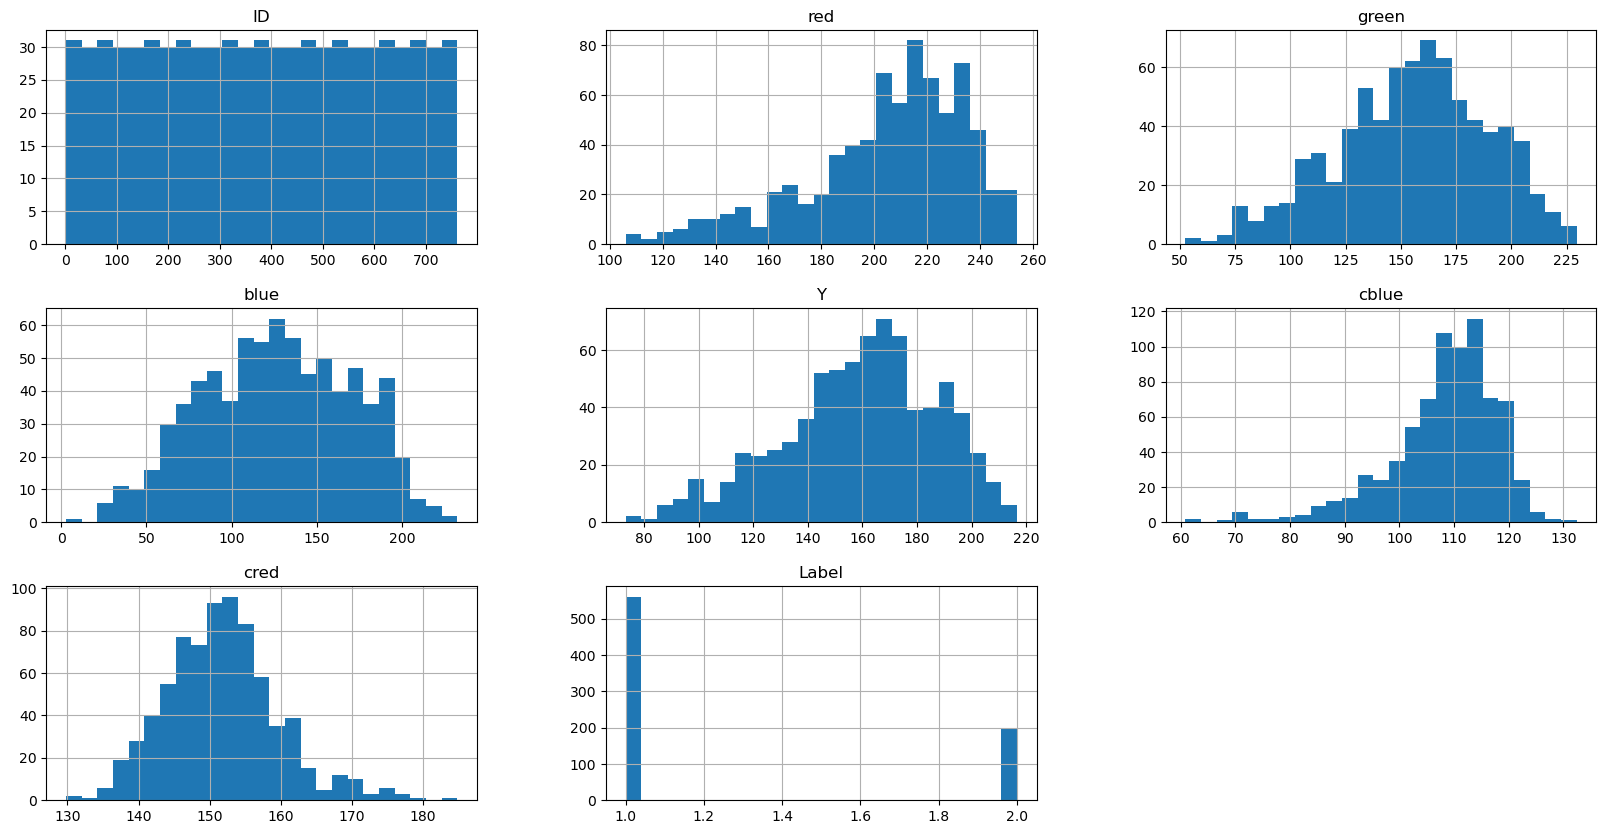

In [6]:
df.hist(bins=25,figsize=(20,10))

Label
1    561
2    200
Name: count, dtype: int64


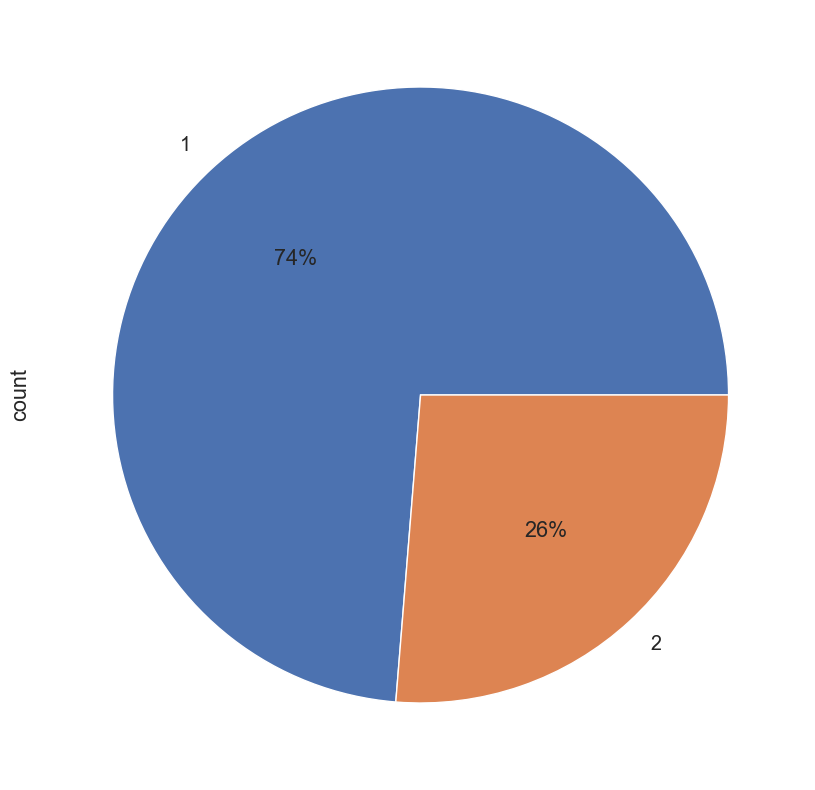

In [7]:
sns.set(rc={'figure.figsize': [10, 10]}, font_scale=1.3)
df['Label'].value_counts().plot(kind='pie', autopct = "%1.0f%%")
print (df['Label'].value_counts())

In [8]:
#Understand the data
print(df['Label'].value_counts())
print("We have data Imbalance")

Label
1    561
2    200
Name: count, dtype: int64
We have data Imbalance


In [9]:
#Define x and drop ID
X = df.drop(labels = ["Label", "ID"], axis=1)

In [10]:
#Define the dependent variable that needs to be predicted
Y = df["Label"].values
# Encoding categorical data
from sklearn.preprocessing import LabelEncoder
labelencoder = LabelEncoder()
Y = labelencoder.fit_transform(Y)

In [23]:
#Split dataset, training= 80% and testing = 20%.
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.20, random_state=0)


X_resampled = X_train
y_resampled = y_train 

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_54332\3246115236.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


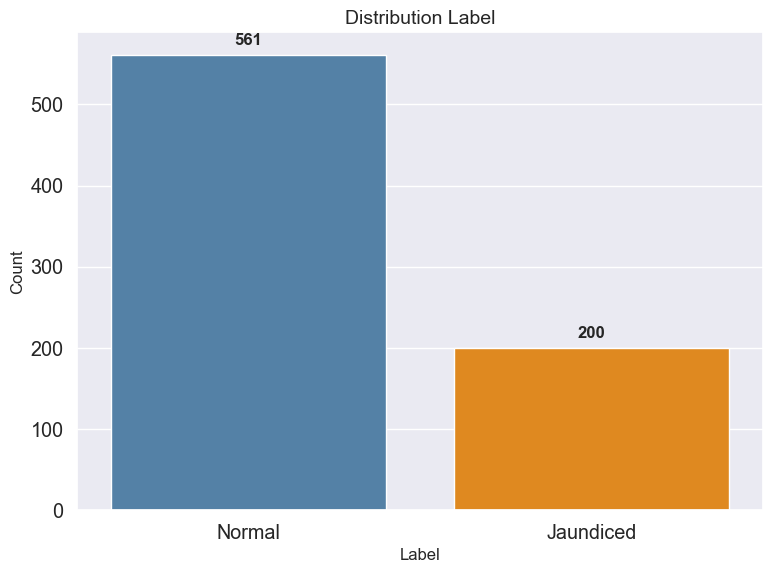

Counts before SMOTE:
Label
Normal       561
Jaundiced    200
Name: count, dtype: int64
Original dataset shape: Counter({0: 561, 1: 200})


In [24]:
label_map = {0: "Normal", 1: "Jaundiced"}
Y_series = pd.Series(Y)
Y_labels = Y_series.map(label_map)

# Create DataFrame for before SMOTE
df_before = pd.DataFrame({"Label": Y_labels})
plt.figure(figsize=(8,6))
ax = sns.countplot(
    x="Label",
    data=df_before,
    palette={"Normal": "steelblue", "Jaundiced": "darkorange"}
)

# عرض الأرقام على الأعمدة
for container in ax.containers:
    ax.bar_label(container, fontsize=12, fontweight='bold', label_type='edge', padding=5)

plt.xlabel("Label", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.title("Distribution Label", fontsize=14)
plt.tight_layout()
plt.show()

# Print counts BEFORE
print("Counts before SMOTE:")
print(df_before["Label"].value_counts())
print(f"Original dataset shape: {Counter(Y)}")

Accuracy: 0.934640522875817
Precision: 0.9033555729984302
Recall: 0.9476263066202091
F1 Score: 0.9212962962962963
AUC: 0.947626306620209
MCC: 0.8498295485471553
Confusion Matrix:
 [[103   9]
 [  1  40]]
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.92      0.95       112
           1       0.82      0.98      0.89        41

    accuracy                           0.93       153
   macro avg       0.90      0.95      0.92       153
weighted avg       0.94      0.93      0.94       153



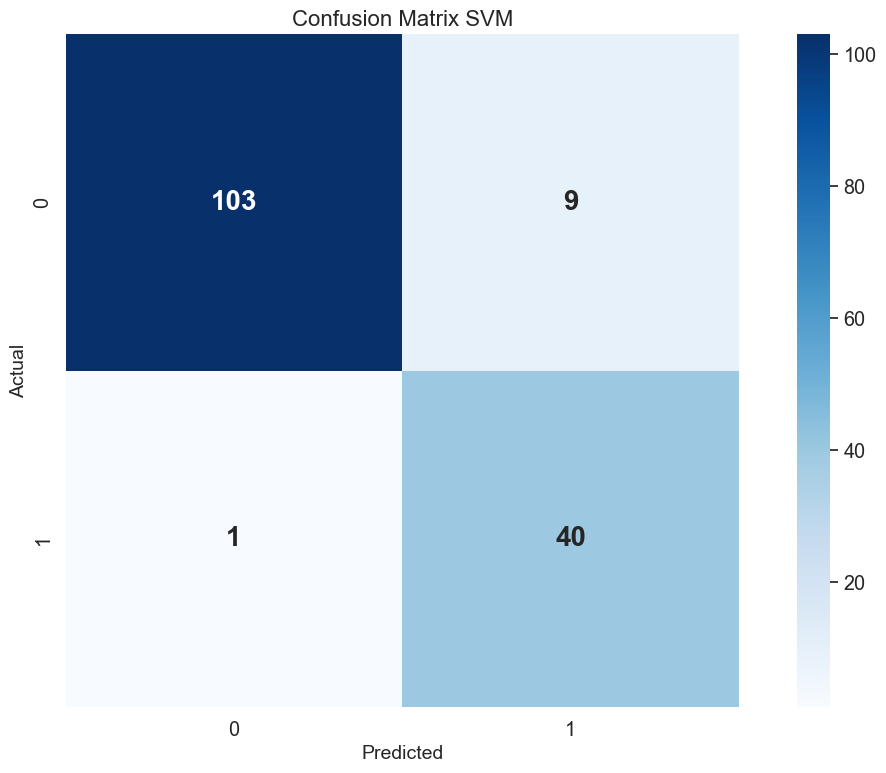

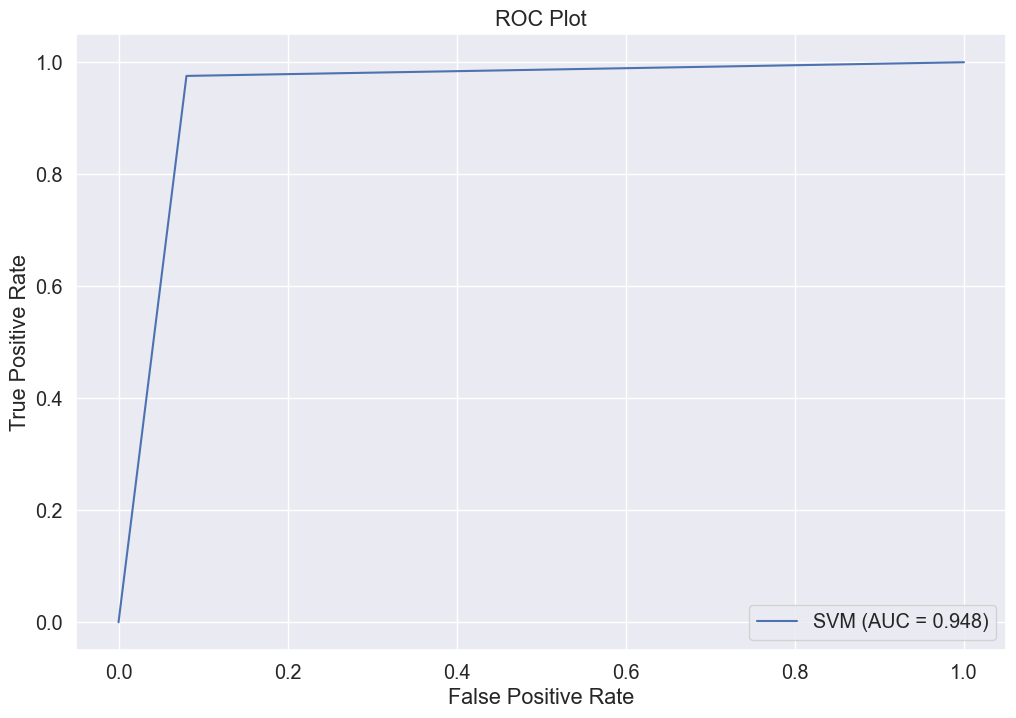

In [35]:
# Initialize the SVM classifier
svm_model = SVC(C=1.0, kernel='rbf', degree=2)

# Train the SVM classifier
svm_model.fit(X_resampled, y_resampled)

# Predict on the test set
predictions_svm = svm_model.predict(X_test)

# Evaluate performance
accuracy = accuracy_score(y_test, predictions_svm)
precision = precision_score(y_test, predictions_svm, average='macro')
recall = recall_score(y_test, predictions_svm, average='macro')
f1 = f1_score(y_test, predictions_svm, average='macro')
auc = roc_auc_score(y_test, predictions_svm)
mcc = matthews_corrcoef(y_test, predictions_svm)
conf_matrix = confusion_matrix(y_test, predictions_svm)

# Print evaluation metrics
print('Accuracy:', accuracy)
print('Precision:', precision)
print('Recall:', recall)
print('F1 Score:', f1)
print('AUC:', auc)
print('MCC:', mcc)
print('Confusion Matrix:\n', conf_matrix)
print('Classification Report:\n', classification_report(y_test, predictions_svm))


plt.figure(figsize=(12, 8))
sns.heatmap(conf_matrix, 
            annot=True, 
            fmt="0.0f", 
            cmap="Blues", 
            square=True,
            annot_kws={'size': 20, 'weight': 'bold'})  # تكبير الأرقام
plt.ylabel('Actual', fontsize=14)
plt.xlabel('Predicted', fontsize=14)
plt.title('Confusion Matrix SVM', fontsize=16)
plt.tight_layout()
plt.show()

# Plot ROC curve
svm_auc = roc_auc_score(y_test, predictions_svm)
svm_fpr, svm_tpr, _ = roc_curve(y_test, predictions_svm)
plt.figure(figsize=(12, 8))
plt.plot(svm_fpr, svm_tpr, label='SVM (AUC = %0.3f)' % svm_auc)
plt.title('ROC Plot')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()


Accuracy: 0.9281045751633987
Precision: 0.8967261904761905
Recall: 0.9354311846689896
F1 Score: 0.9128566250711956
AUC: 0.9354311846689896
MCC: 0.8312567716614712
Confusion Matrix:
 [[103   9]
 [  2  39]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.92      0.95       112
           1       0.81      0.95      0.88        41

    accuracy                           0.93       153
   macro avg       0.90      0.94      0.91       153
weighted avg       0.94      0.93      0.93       153



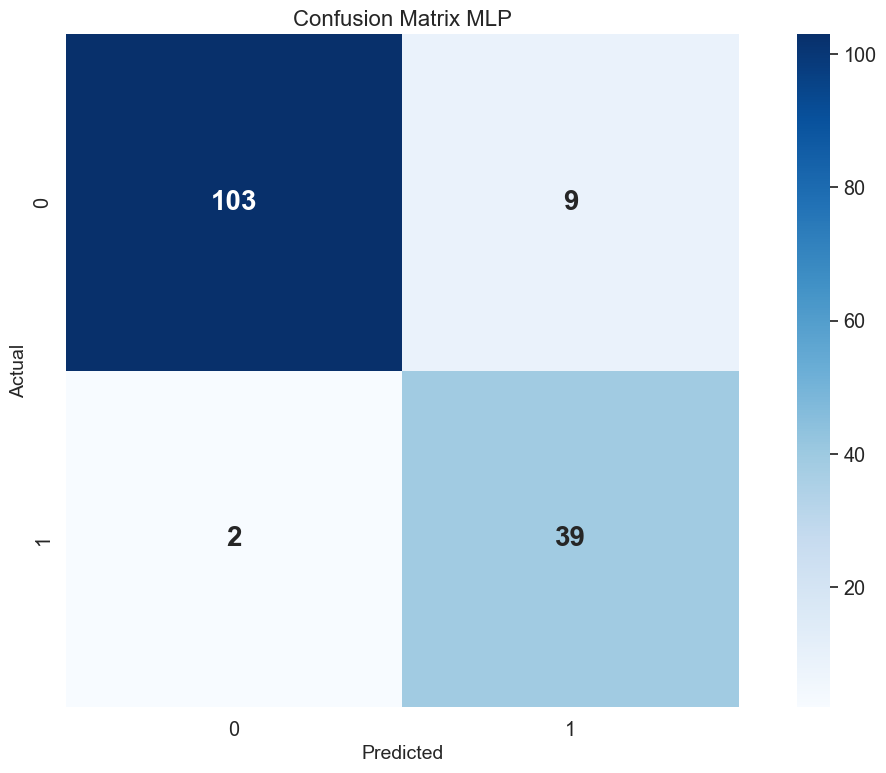

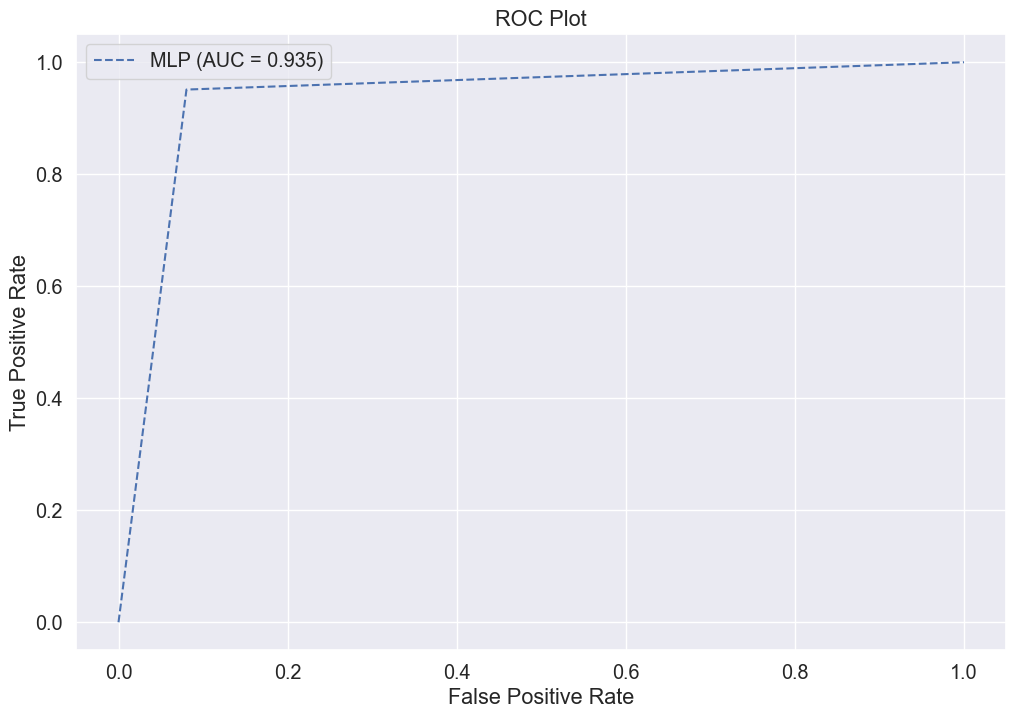

In [36]:
# Initialize the MLP classifier
mlp_model = MLPClassifier(hidden_layer_sizes=(100,), activation='relu', solver='adam', alpha=0.0001, batch_size='auto', learning_rate='constant', learning_rate_init=0.001)

# Train the MLP classifier
mlp_model.fit(X_resampled, y_resampled)

# Predict on the test set
predictions_mlp = mlp_model.predict(X_test)

# Evaluate performance
accuracy = accuracy_score(y_test, predictions_mlp)
precision = precision_score(y_test, predictions_mlp, average='macro')
recall = recall_score(y_test, predictions_mlp, average='macro')
f1 = f1_score(y_test, predictions_mlp, average='macro')
auc = roc_auc_score(y_test, predictions_mlp)
mcc = matthews_corrcoef(y_test, predictions_mlp)
conf_matrix = confusion_matrix(y_test, predictions_mlp)

# Print evaluation metrics
print('Accuracy:', accuracy)
print('Precision:', precision)
print('Recall:', recall)
print('F1 Score:', f1)
print('AUC:', auc)
print('MCC:', mcc)
print('Confusion Matrix:\n', conf_matrix)
print('Classification Report:\n', classification_report(y_test, predictions_mlp))

# Plot confusion matrix
plt.figure(figsize=(12, 8))
sns.heatmap(conf_matrix, 
            annot=True, 
            fmt="0.0f", 
            cmap="Blues", 
            square=True,
            annot_kws={'size': 20, 'weight': 'bold'})  # تكبير الأرقام
plt.ylabel('Actual', fontsize=14)
plt.xlabel('Predicted', fontsize=14)
plt.title('Confusion Matrix MLP', fontsize=16)
plt.tight_layout()
plt.show()

# Plot ROC curve
mlp_auc = roc_auc_score(y_test, predictions_mlp)
mlp_fpr, mlp_tpr, _ = roc_curve(y_test, predictions_mlp)
plt.figure(figsize=(12, 8))
plt.plot(mlp_fpr, mlp_tpr, linestyle='--', label='MLP (AUC = %0.3f)' % mlp_auc)
plt.title('ROC Plot')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()


Accuracy: 0.9215686274509803
Precision: 0.8925925925925926
Recall: 0.9155052264808363
F1 Score: 0.9029598308668076
AUC: 0.9155052264808362
MCC: 0.8077729237846089
Confusion Matrix:
 [[104   8]
 [  4  37]]
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.93      0.95       112
           1       0.82      0.90      0.86        41

    accuracy                           0.92       153
   macro avg       0.89      0.92      0.90       153
weighted avg       0.93      0.92      0.92       153



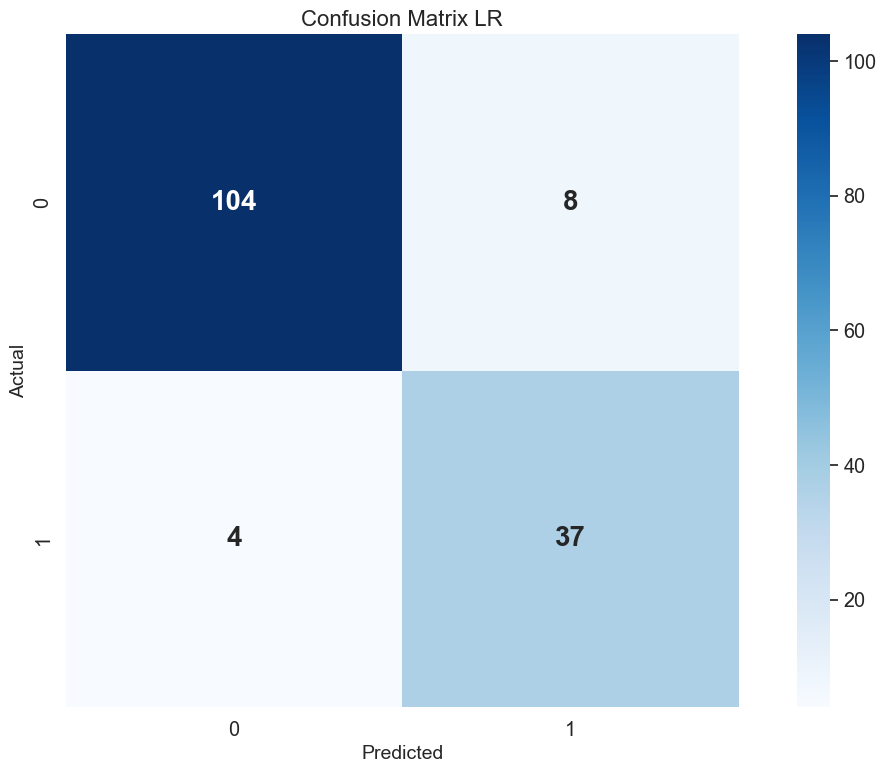

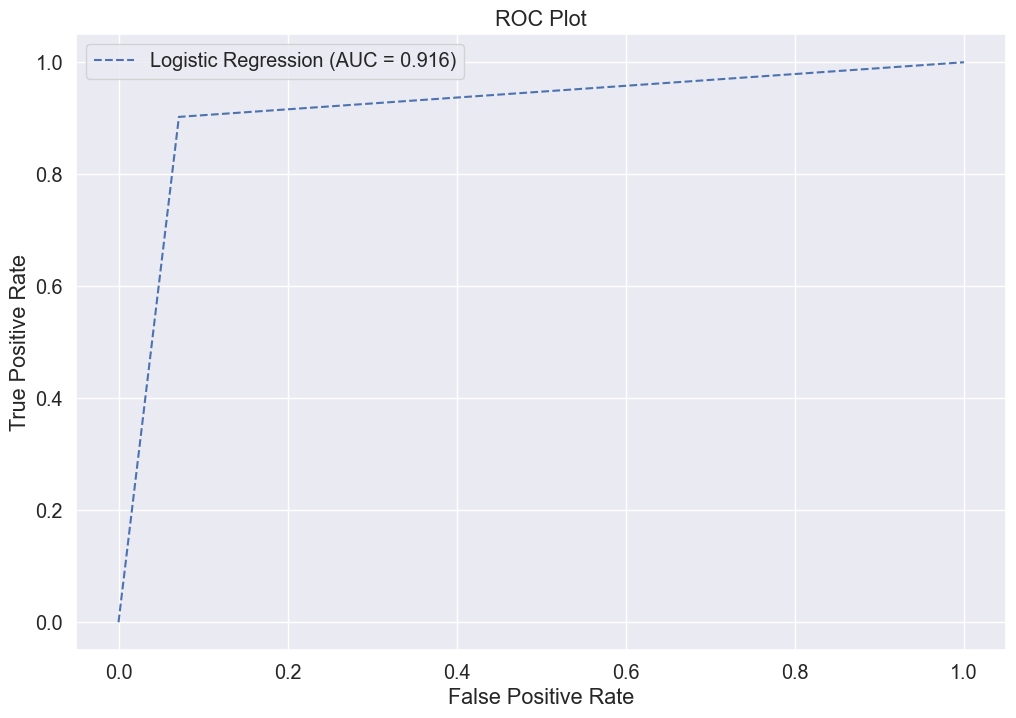

In [37]:
# Initialize the Logistic Regression model (LR)
logreg_model = LogisticRegression(penalty='l2', dual=False, tol=0.0001, C=1.0, random_state=42)

# Train the Logistic Regression model
logreg_model.fit(X_resampled, y_resampled)

# Predict on the test set
predictions_logreg = logreg_model.predict(X_test)

# Evaluate performance
accuracy = accuracy_score(y_test, predictions_logreg)
precision = precision_score(y_test, predictions_logreg, average='macro')
recall = recall_score(y_test, predictions_logreg, average='macro')
f1 = f1_score(y_test, predictions_logreg, average='macro')
auc = roc_auc_score(y_test, predictions_logreg)
mcc = matthews_corrcoef(y_test, predictions_logreg)
conf_matrix = confusion_matrix(y_test, predictions_logreg)

# Print evaluation metrics
print('Accuracy:', accuracy)
print('Precision:', precision)
print('Recall:', recall)
print('F1 Score:', f1)
print('AUC:', auc)
print('MCC:', mcc)
print('Confusion Matrix:\n', conf_matrix)
print('Classification Report:\n', classification_report(y_test, predictions_logreg))

# Plot confusion matrix
plt.figure(figsize=(12, 8))
sns.heatmap(conf_matrix, 
            annot=True, 
            fmt="0.0f", 
            cmap="Blues", 
            square=True,
            annot_kws={'size': 20, 'weight': 'bold'})  # تكبير الأرقام
plt.ylabel('Actual', fontsize=14)
plt.xlabel('Predicted', fontsize=14)
plt.title('Confusion Matrix LR', fontsize=16)
plt.tight_layout()
plt.show()

# Plot ROC curve
logreg_auc = roc_auc_score(y_test, predictions_logreg)
logreg_fpr, logreg_tpr, _ = roc_curve(y_test, predictions_logreg)
plt.figure(figsize=(12, 8))
plt.plot(logreg_fpr, logreg_tpr, linestyle='--', label='Logistic Regression (AUC = %0.3f)' % logreg_auc)
plt.title('ROC Plot')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()


C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Accuracy: 0.9803921568627451
Precision: 0.9716859716859716
Recall: 0.9788763066202091
F1 Score: 0.9752012534442703
AUC: 0.9788763066202091
MCC: 0.9505350830043943
Confusion Matrix:
 [[110   2]
 [  1  40]]
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.99       112
           1       0.95      0.98      0.96        41

    accuracy                           0.98       153
   macro avg       0.97      0.98      0.98       153
weighted avg       0.98      0.98      0.98       153



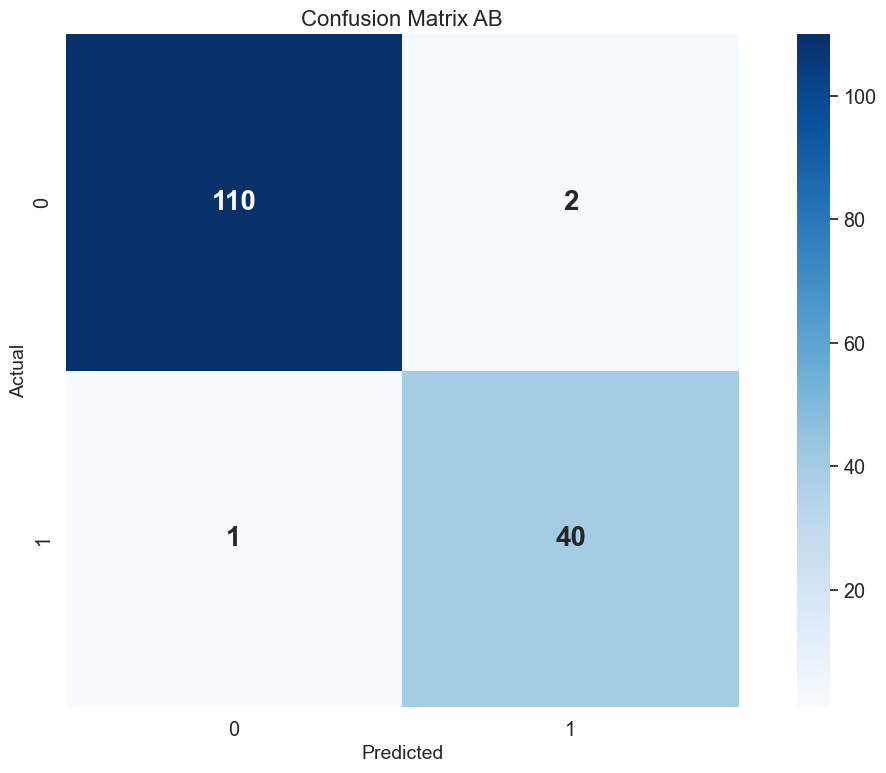

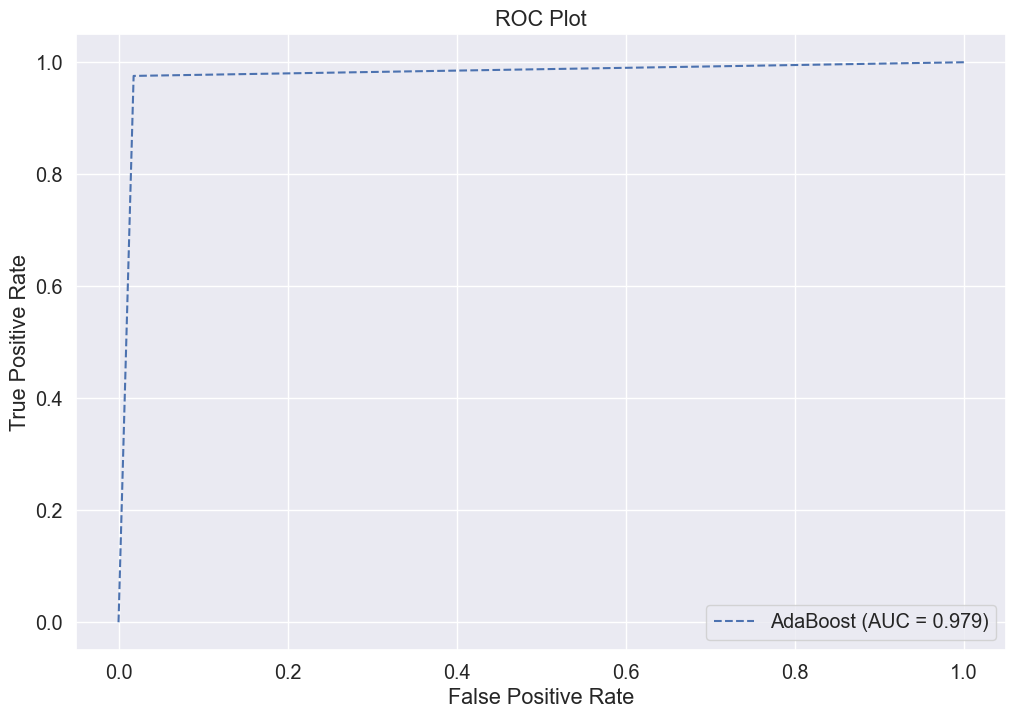

In [38]:
# Initialize the AdaBoost classifier
adaboost_model = AdaBoostClassifier(n_estimators=50, learning_rate=1.0,random_state=42)

# Train the AdaBoost classifier
adaboost_model.fit(X_resampled, y_resampled)

# Predict on the test set
predictions_adaboost = adaboost_model.predict(X_test)

# Evaluate performance
accuracy = accuracy_score(y_test, predictions_adaboost)
precision = precision_score(y_test, predictions_adaboost, average='macro')
recall = recall_score(y_test, predictions_adaboost, average='macro')
f1 = f1_score(y_test, predictions_adaboost, average='macro')
auc = roc_auc_score(y_test, predictions_adaboost)
mcc = matthews_corrcoef(y_test, predictions_adaboost)
conf_matrix = confusion_matrix(y_test, predictions_adaboost)

# Print evaluation metrics
print('Accuracy:', accuracy)
print('Precision:', precision)
print('Recall:', recall)
print('F1 Score:', f1)
print('AUC:', auc)
print('MCC:', mcc)
print('Confusion Matrix:\n', conf_matrix)
print('Classification Report:\n', classification_report(y_test, predictions_adaboost))

# Plot confusion matrix
plt.figure(figsize=(12, 8))
sns.heatmap(conf_matrix, 
            annot=True, 
            fmt="0.0f", 
            cmap="Blues", 
            square=True,
            annot_kws={'size': 20, 'weight': 'bold'})  # تكبير الأرقام
plt.ylabel('Actual', fontsize=14)
plt.xlabel('Predicted', fontsize=14)
plt.title('Confusion Matrix AB', fontsize=16)
plt.tight_layout()
plt.show()

# Plot ROC curve
adaboost_auc = roc_auc_score(y_test, predictions_adaboost)
adaboost_fpr, adaboost_tpr, _ = roc_curve(y_test, predictions_adaboost)
plt.figure(figsize=(12, 8))
plt.plot(adaboost_fpr, adaboost_tpr, linestyle='--', label='AdaBoost (AUC = %0.3f)' % adaboost_auc)
plt.title('ROC Plot')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()


Accuracy: 0.9803921568627451
Precision: 0.9786504424778761
Recall: 0.9711454703832753
F1 Score: 0.9748148148148148
AUC: 0.9711454703832754
MCC: 0.9497662614989054
Confusion Matrix:
 [[111   1]
 [  2  39]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99       112
           1       0.97      0.95      0.96        41

    accuracy                           0.98       153
   macro avg       0.98      0.97      0.97       153
weighted avg       0.98      0.98      0.98       153



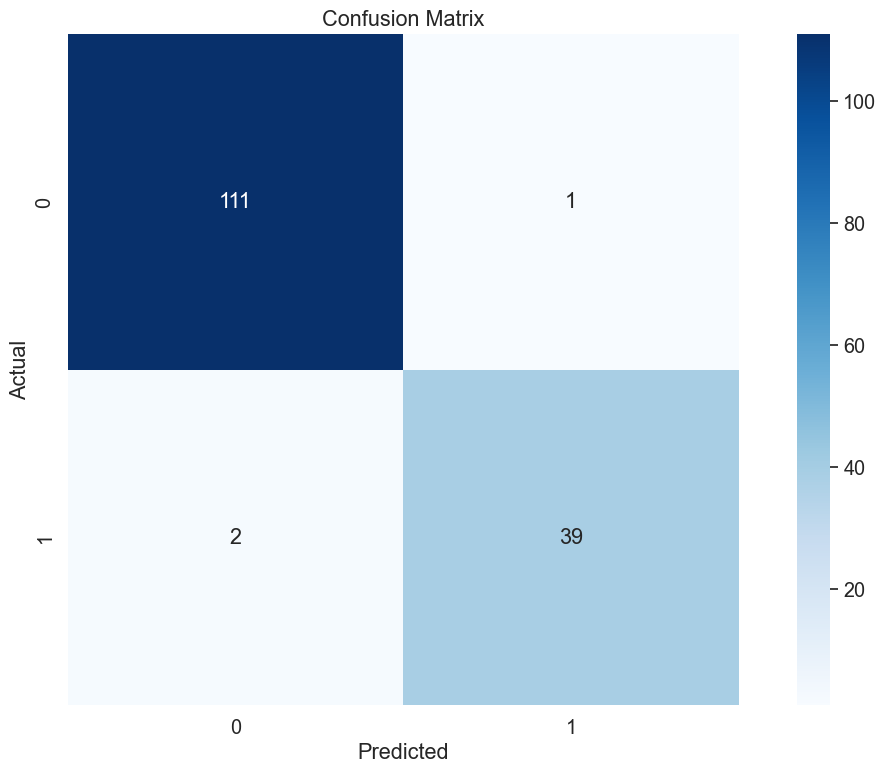

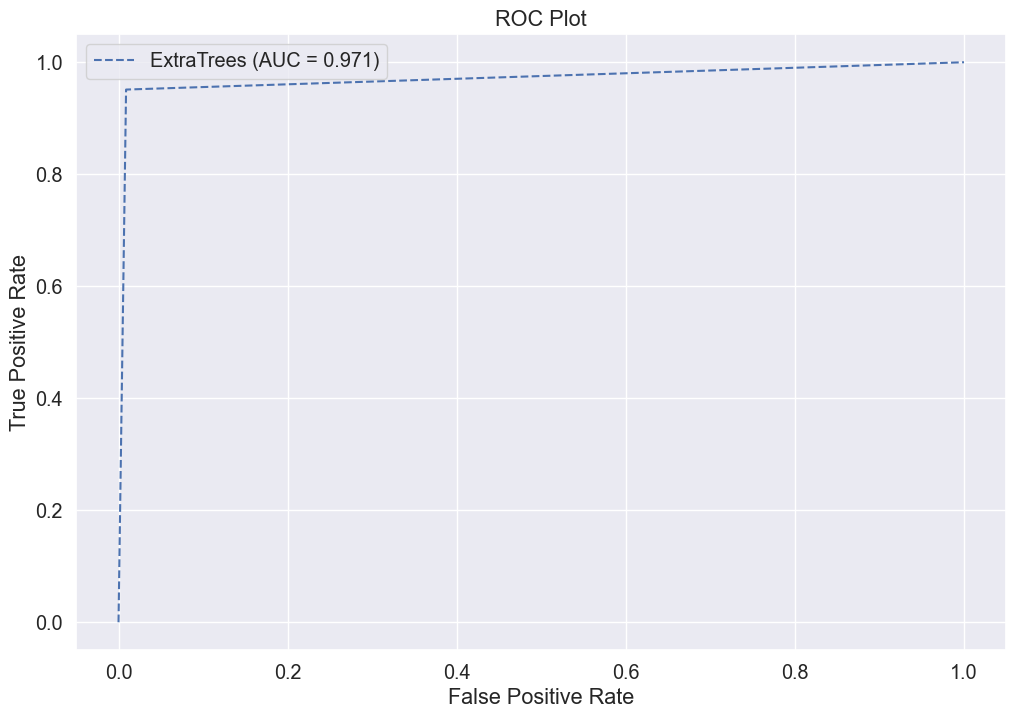

In [29]:
# Initialize the ExtraTrees classifier
extratrees_model = ExtraTreesClassifier(n_estimators=50, criterion='gini', max_depth=None, min_samples_split=2,random_state=42)

# Train the ExtraTrees classifier
extratrees_model.fit(X_resampled, y_resampled)

# Predict on the test set
predictions_extratrees = extratrees_model.predict(X_test)

# Evaluate performance
accuracy = accuracy_score(y_test, predictions_extratrees)
precision = precision_score(y_test, predictions_extratrees, average='macro')
recall = recall_score(y_test, predictions_extratrees, average='macro')
f1 = f1_score(y_test, predictions_extratrees, average='macro')
auc = roc_auc_score(y_test, predictions_extratrees)
mcc = matthews_corrcoef(y_test, predictions_extratrees)
conf_matrix = confusion_matrix(y_test, predictions_extratrees)

# Print evaluation metrics
print('Accuracy:', accuracy)
print('Precision:', precision)
print('Recall:', recall)
print('F1 Score:', f1)
print('AUC:', auc)
print('MCC:', mcc)
print('Confusion Matrix:\n', conf_matrix)
print('Classification Report:\n', classification_report(y_test, predictions_extratrees))

# Plot confusion matrix
plt.figure(figsize=(12, 8))
sns.heatmap(conf_matrix, annot=True, fmt="0.0f",cmap="Blues",square=True)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

# Plot ROC curve
extratrees_auc = roc_auc_score(y_test, predictions_extratrees)
extratrees_fpr, extratrees_tpr, _ = roc_curve(y_test, predictions_extratrees)
plt.figure(figsize=(12, 8))
plt.plot(extratrees_fpr, extratrees_tpr, linestyle='--', label='ExtraTrees (AUC = %0.3f)' % extratrees_auc)
plt.title('ROC Plot')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()


Accuracy: 0.9215686274509803
Precision: 0.8958773784355181
Recall: 0.9077743902439024
F1 Score: 0.9015444015444015
AUC: 0.9077743902439024
MCC: 0.8035637040157997
Confusion Matrix:
 [[105   7]
 [  5  36]]
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.94      0.95       112
           1       0.84      0.88      0.86        41

    accuracy                           0.92       153
   macro avg       0.90      0.91      0.90       153
weighted avg       0.92      0.92      0.92       153



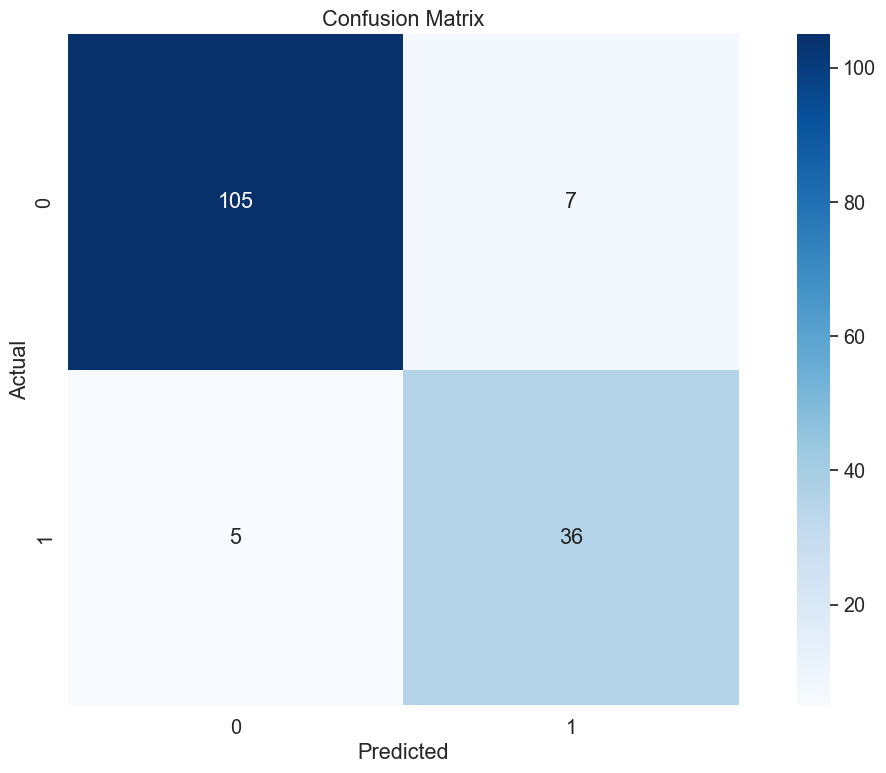

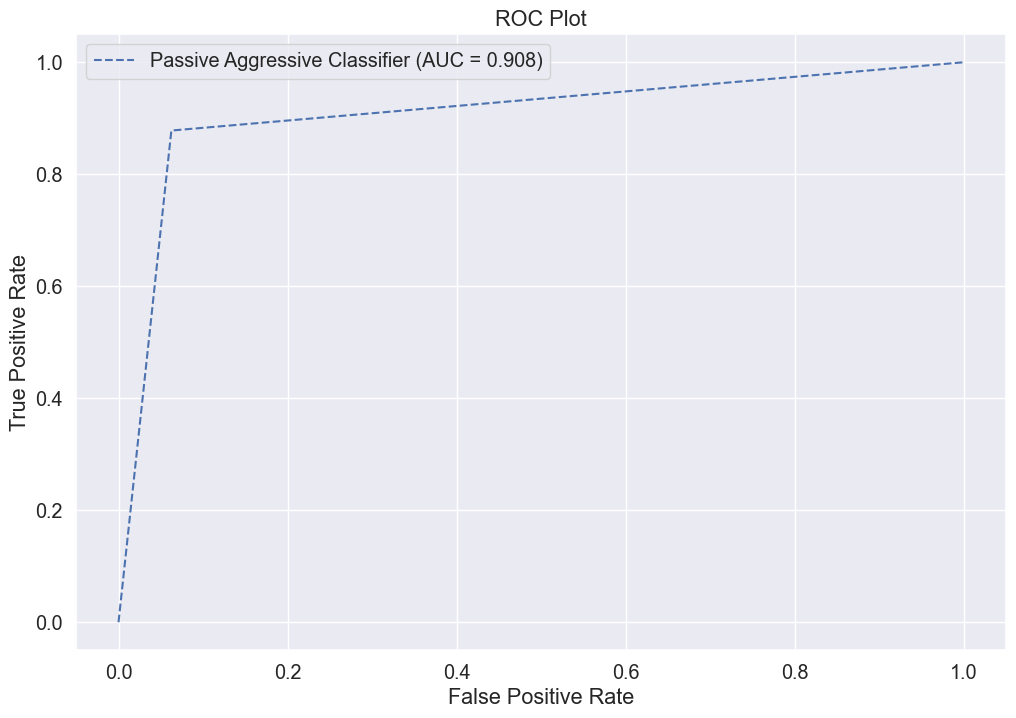

In [31]:
# Initialize the Passive Aggressive Classifier
pac_model = PassiveAggressiveClassifier(C=1.0, fit_intercept=True, max_iter=1000, tol=0.001,random_state=42)

# Train the Passive Aggressive Classifier
pac_model.fit(X_resampled, y_resampled)

# Predict on the test set
predictions_pac = pac_model.predict(X_test)

# Evaluate performance
accuracy = accuracy_score(y_test, predictions_pac)
precision = precision_score(y_test, predictions_pac, average='macro')
recall = recall_score(y_test, predictions_pac, average='macro')
f1 = f1_score(y_test, predictions_pac, average='macro')
auc = roc_auc_score(y_test, predictions_pac)
mcc = matthews_corrcoef(y_test, predictions_pac)
conf_matrix = confusion_matrix(y_test, predictions_pac)

# Print evaluation metrics
print('Accuracy:', accuracy)
print('Precision:', precision)
print('Recall:', recall)
print('F1 Score:', f1)
print('AUC:', auc)
print('MCC:', mcc)
print('Confusion Matrix:\n', conf_matrix)
print('Classification Report:\n', classification_report(y_test, predictions_pac))

# Plot confusion matrix
plt.figure(figsize=(12, 8))
sns.heatmap(conf_matrix, annot=True, fmt="0.0f",cmap="Blues",square=True)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

# Plot ROC curve
pac_auc = roc_auc_score(y_test, predictions_pac)
pac_fpr, pac_tpr, _ = roc_curve(y_test, predictions_pac)
plt.figure(figsize=(12, 8))
plt.plot(pac_fpr, pac_tpr, linestyle='--', label='Passive Aggressive Classifier (AUC = %0.3f)' % pac_auc)
plt.title('ROC Plot')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()


Accuracy: 0.9869281045751634
Precision: 0.9833405923344948
Recall: 0.9833405923344948
F1 Score: 0.9833405923344948
AUC: 0.9833405923344948
MCC: 0.9666811846689896
Confusion Matrix:
 [[111   1]
 [  1  40]]
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       112
           1       0.98      0.98      0.98        41

    accuracy                           0.99       153
   macro avg       0.98      0.98      0.98       153
weighted avg       0.99      0.99      0.99       153



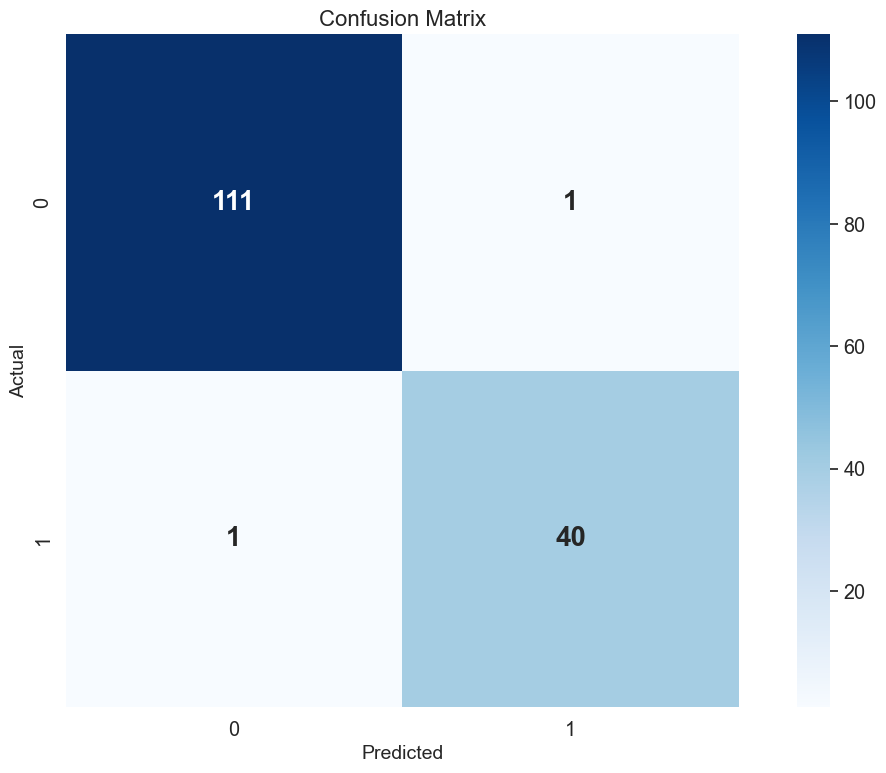

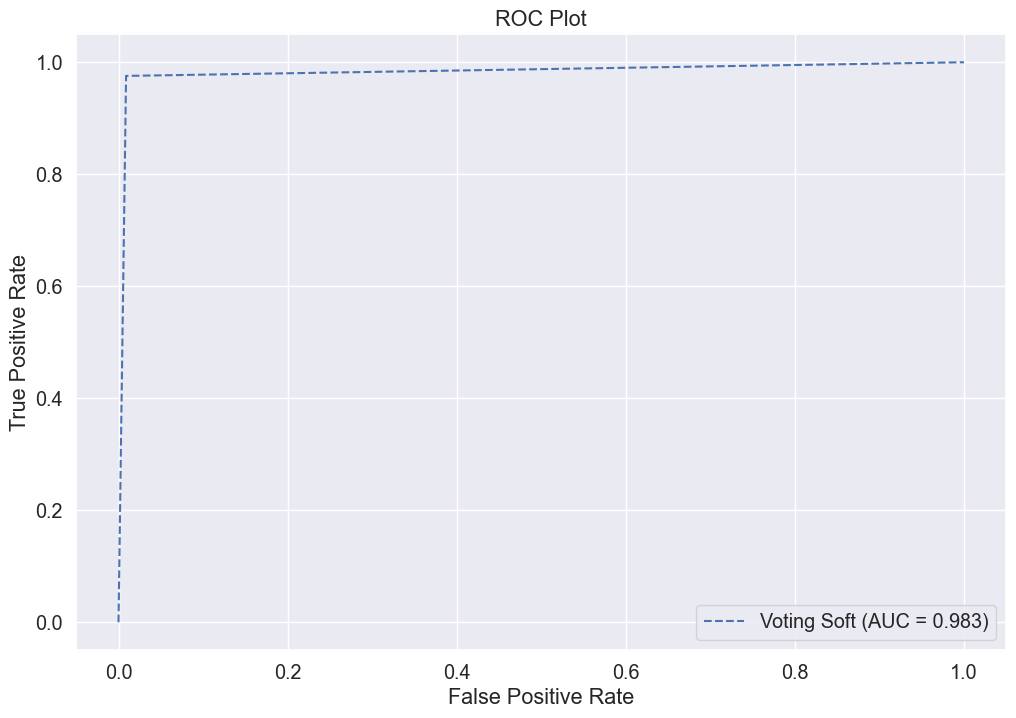

In [32]:
# Initialize the AdaBoost and ExtraTrees classifier
AdaBoost_model = AdaBoostClassifier(n_estimators=50, learning_rate=1.0,random_state=42)
extratrees_model = ExtraTreesClassifier(n_estimators=50, criterion='gini', max_depth=None, min_samples_split=2,random_state=42)



# Train the Gradient Boosting classifier
gradientboost_model.fit(X_resampled, y_resampled)

# Train the ExtraTrees classifier
extratrees_model.fit(X_resampled, y_resampled)

# Create a Voting Classifier with both Gradient Boosting and ExtraTrees
voting_model = VotingClassifier(estimators=[('gb', gradientboost_model), ('et', extratrees_model)], voting='soft')

# Train the Voting Classifier
voting_model.fit(X_resampled, y_resampled)

# Predict on the test set with Voting Classifier
predictions_voting = voting_model.predict(X_test)

# Evaluate performance
accuracy = accuracy_score(y_test, predictions_voting)
precision = precision_score(y_test, predictions_voting, average='macro')
recall = recall_score(y_test, predictions_voting, average='macro')
f1 = f1_score(y_test, predictions_voting, average='macro')
auc = roc_auc_score(y_test, predictions_voting)
mcc = matthews_corrcoef(y_test, predictions_voting)
conf_matrix = confusion_matrix(y_test, predictions_voting)

# Print evaluation metrics
print('Accuracy:', accuracy)
print('Precision:', precision)
print('Recall:', recall)
print('F1 Score:', f1)
print('AUC:', auc)
print('MCC:', mcc)
print('Confusion Matrix:\n', conf_matrix)
print('Classification Report:\n', classification_report(y_test, predictions_voting))

# Plot confusion matrix
plt.figure(figsize=(12, 8))
sns.heatmap(conf_matrix, 
            annot=True, 
            fmt="0.0f", 
            cmap="Blues", 
            square=True,
            annot_kws={'size': 20, 'weight': 'bold'})  # تكبير الأرقام
plt.ylabel('Actual', fontsize=14)
plt.xlabel('Predicted', fontsize=14)
plt.title('Confusion Matrix', fontsize=16)
plt.tight_layout()
plt.show()

# Plot ROC curve
voting_aucs = roc_auc_score(y_test, predictions_voting)
voting_fprs, voting_tprs, _ = roc_curve(y_test, predictions_voting)
plt.figure(figsize=(12, 8))
plt.plot(voting_fprs, voting_tprs, linestyle='--', label='Voting Soft (AUC = %0.3f)' % voting_aucs)
plt.title('ROC Plot')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()


Accuracy: 0.9738562091503268
Precision: 0.9740215924426451
Recall: 0.9589503484320558
F1 Score: 0.9661504424778761
AUC: 0.9589503484320557
MCC: 0.9328502023709271
Confusion Matrix:
 [[111   1]
 [  3  38]]
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98       112
           1       0.97      0.93      0.95        41

    accuracy                           0.97       153
   macro avg       0.97      0.96      0.97       153
weighted avg       0.97      0.97      0.97       153



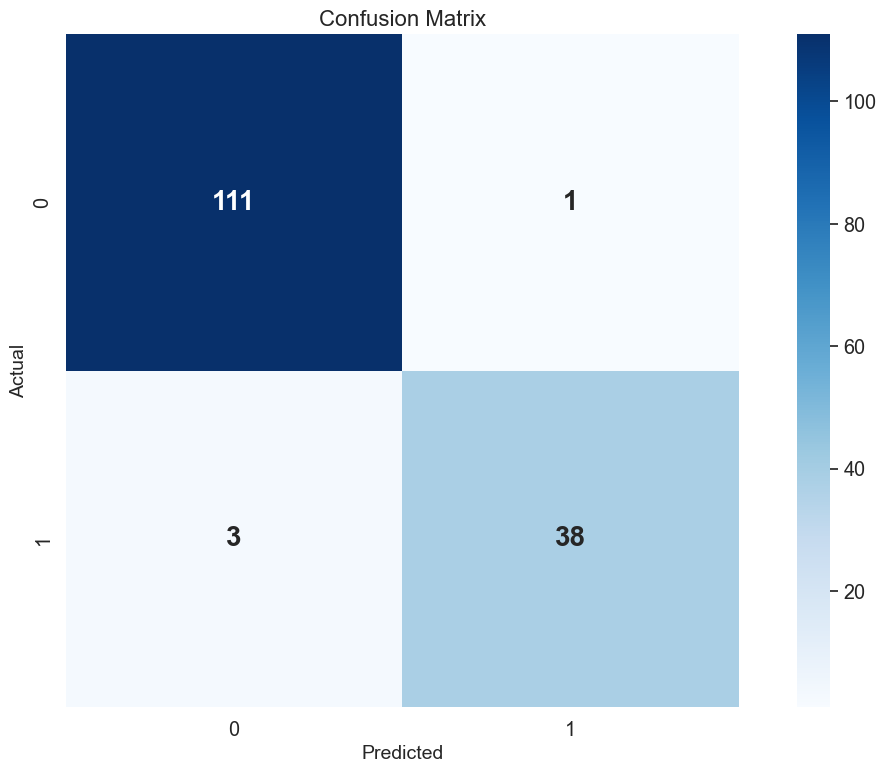

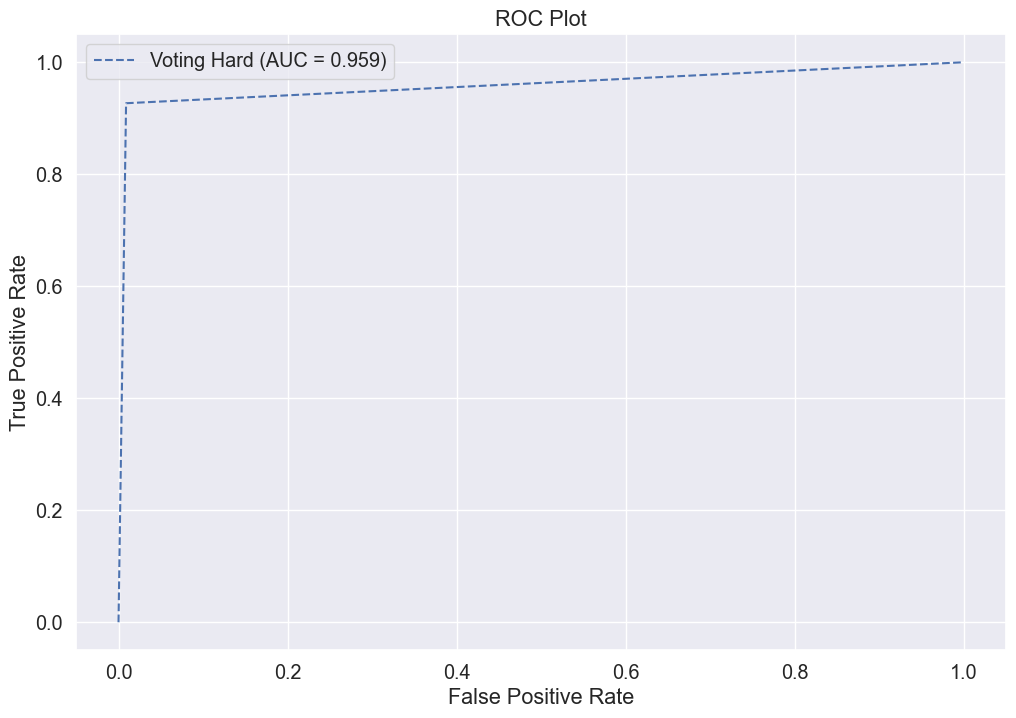

In [33]:
# Initialize the AdaBoost g and ExtraTrees classifier
AdaBoost_model = AdaBoostClassifier(n_estimators=50, learning_rate=1.0,random_state=42)
extratrees_model = ExtraTreesClassifier(n_estimators=50, criterion='gini', max_depth=None, min_samples_split=2,random_state=42)



# Train the Gradient Boosting classifier
gradientboost_model.fit(X_resampled, y_resampled)

# Train the ExtraTrees classifier
extratrees_model.fit(X_resampled, y_resampled)

# Create a Voting Classifier with both Gradient Boosting and ExtraTrees
voting_model = VotingClassifier(estimators=[('gb', gradientboost_model), ('et', extratrees_model)], voting='hard')

# Train the Voting Classifier
voting_model.fit(X_resampled, y_resampled)

# Predict on the test set with Voting Classifier
predictions_voting = voting_model.predict(X_test)

# Evaluate performance
accuracy = accuracy_score(y_test, predictions_voting)
precision = precision_score(y_test, predictions_voting, average='macro')
recall = recall_score(y_test, predictions_voting, average='macro')
f1 = f1_score(y_test, predictions_voting, average='macro')
auc = roc_auc_score(y_test, predictions_voting)
mcc = matthews_corrcoef(y_test, predictions_voting)
conf_matrix = confusion_matrix(y_test, predictions_voting)

# Print evaluation metrics
print('Accuracy:', accuracy)
print('Precision:', precision)
print('Recall:', recall)
print('F1 Score:', f1)
print('AUC:', auc)
print('MCC:', mcc)
print('Confusion Matrix:\n', conf_matrix)
print('Classification Report:\n', classification_report(y_test, predictions_voting))

# Plot confusion matrix
plt.figure(figsize=(12, 8))
sns.heatmap(conf_matrix, 
            annot=True, 
            fmt="0.0f", 
            cmap="Blues", 
            square=True,
            annot_kws={'size': 20, 'weight': 'bold'})  # 
plt.ylabel('Actual', fontsize=14)
plt.xlabel('Predicted', fontsize=14)
plt.title('Confusion Matrix', fontsize=16)
plt.tight_layout()
plt.show()

# Plot ROC curve
voting_auch = roc_auc_score(y_test, predictions_voting)
voting_fprh, voting_tprh, _ = roc_curve(y_test, predictions_voting)
plt.figure(figsize=(12, 8))
plt.plot(voting_fprh, voting_tprh, linestyle='--', label='Voting Hard (AUC = %0.3f)' % voting_auch)
plt.title('ROC Plot')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()


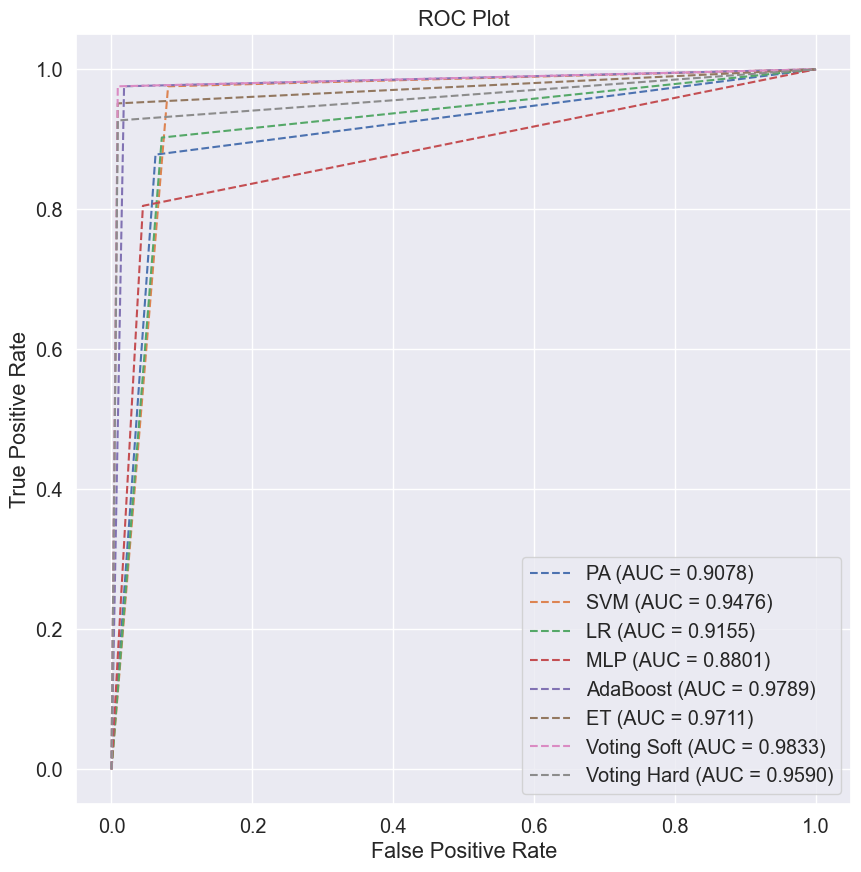

In [34]:
# plt.figure(figsize=(14, 9))

plt.plot(pac_fpr, pac_tpr, linestyle='--', label='PA (AUC = %0.4f)' % pac_auc)

plt.plot(svm_fpr, svm_tpr, linestyle='--', label='SVM (AUC = %0.4f)' % svm_auc)

plt.plot(logreg_fpr, logreg_tpr, linestyle='--', label='LR (AUC = %0.4f)' % logreg_auc)

plt.plot(mlp_fpr, mlp_tpr, linestyle='--', label='MLP (AUC = %0.4f)' % mlp_auc)

plt.plot(adaboost_fpr, adaboost_tpr, linestyle='--', label='AdaBoost (AUC = %0.4f)' % adaboost_auc)

plt.plot(extratrees_fpr, extratrees_tpr, linestyle='--', label='ET (AUC = %0.4f)' % extratrees_auc)


plt.plot(voting_fprs, voting_tprs, linestyle='--', label='Voting Soft (AUC = %0.4f)' % voting_aucs)

plt.plot(voting_fprh, voting_tprh, linestyle='--', label='Voting Hard (AUC = %0.4f)' % voting_auch)


plt.title('ROC Plot')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()